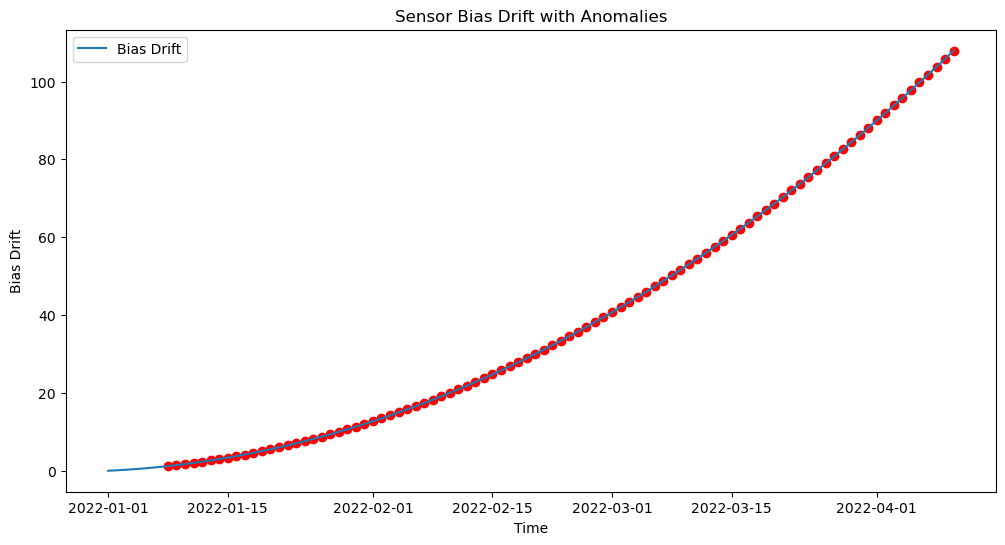

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Example data
data = {
    'time': pd.date_range(start='1/1/2022', periods=100, freq='D'),
    'bias_drift': [0.1 * i + 0.01 * i**2 for i in range(100)]
}
drift_data = pd.DataFrame(data)

# Define the drift threshold
drift_threshold = 1.0

# Detect anomalies
drift_data['anomaly'] = drift_data['bias_drift'].apply(lambda x: 1 if x > drift_threshold else 0)

# Plot the drift data
plt.figure(figsize=(12, 6))
plt.plot(drift_data['time'], drift_data['bias_drift'], label='Bias Drift')
plt.title('Sensor Bias Drift with Anomalies')
plt.xlabel('Time')
plt.ylabel('Bias Drift')
plt.legend()

# Highlight anomalies
anomaly_times = drift_data[drift_data['anomaly'] == 1]['time']
anomaly_drift = drift_data[drift_data['anomaly'] == 1]['bias_drift']
plt.scatter(anomaly_times, anomaly_drift, color='red', label='Anomalies')

plt.show()